# Model Tuning and Error Analysis

**Applied ML in Production · Session 6**

---

Session 5 left us stuck. The charter wants 60% of defaults caught while flagging
at most a quarter of applications. Our model reaches 51% at that capacity, and
costs the lender NPR 55 million a quarter.

The instinct at this point is to tune. Search the hyperparameters, try a bigger
model, collect more data. We will do all three — carefully, with cross-validation
— and every one of them will fail.

Then we will find NPR 8.6 million by **looking at where the model is wrong**,
without retraining anything.

That order is deliberate. Tuning is the thing everyone reaches for and error
analysis is the thing that usually pays.

## How to work through this

Type the code. The searches here run in a couple of seconds each, so you can
experiment freely.

Run each cell, read the output, then read the commentary. If a cell errors, run
from the top.

## Learning objectives

After this session you will be able to:

- Explain why a single train/test split is not enough, and use **cross-validation**
  correctly.
- Read fold-to-fold variation and know how much of a score difference is noise.
- Run **grid**, **random** and **halving** search, and say when each is worth it.
- Diagnose over- and underfitting from a **validation curve** and a **learning
  curve**.
- Decide from those curves whether more data, more features, or more capacity is
  the right next investment.
- Run **slice-based error analysis** to find where a model fails.
- Act on a slice finding — including by changing the threshold rather than the model.

## Setup

Same features, same split, same pipeline. Note the test set is created here and
then **not touched again** until the very last cell.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 130)


def find_data(filename="loan_default.csv"):
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"could not find data/{filename}")


loans = pd.read_csv(find_data(), parse_dates=["application_date"])

features = loans[["loan_amount", "tenure_months", "interest_rate", "previous_loans",
                  "days_past_due_history", "annual_income", "credit_score",
                  "sector", "employment_type", "has_collateral"]].copy()
features["income_missing"] = features["annual_income"].isna().astype(int)
features["score_missing"] = features["credit_score"].isna().astype(int)

X = pd.get_dummies(features, drop_first=True).astype(float)
y = loans["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
medians = X_train.median()
X_train, X_test = X_train.fillna(medians), X_test.fillna(medians)

pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
print(f"train {len(X_train):,}   test {len(X_test):,} (locked away)")

train 9,000   test 3,000 (locked away)


---

## 1. You cannot tune on the test set

Every time you look at the test score and change something, you leak a little
information from it into your decisions. Do that twenty times and the test set is
no longer an honest estimate of anything — it has quietly become a training set
for your judgement.

The fix is a **third slice**. Train on one, tune on another, and open the test set
once, at the end.

Rather than carve out a fixed validation set and lose the data, use
**cross-validation**: split the training data into *k* folds, train on *k − 1* and
validate on the one left out, *k* times, and average.

In [2]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="average_precision")

print("average precision on each fold:", scores.round(3))
print(f"mean {scores.mean():.3f}   standard deviation {scores.std():.3f}")
print(f"range {scores.min():.3f} to {scores.max():.3f}")

average precision on each fold: [0.385 0.353 0.405 0.309 0.366]
mean 0.363   standard deviation 0.032
range 0.309 to 0.405


Look at the spread: **0.309 to 0.405** across five folds of the same data, with
the same model. That is a gap of nearly a tenth, produced entirely by which rows
happened to land where.

Two consequences you will use for the rest of your career.

**A single split can flatter you.** The test-set average precision we have been
quoting since session 5 was 0.381 — near the top of that range. Our honest
expectation is the mean, 0.363.

**Improvements smaller than the fold spread are not improvements.** If a change
moves the mean by 0.01 and the folds vary by 0.03, you have measured nothing.
Always report the standard deviation next to the mean.

**Stratified** folds keep the 13.5% default rate in every fold. Without it, a
fold can end up with noticeably fewer defaults and a wild score.

> **On time-ordered data.** `StratifiedKFold` shuffles, which means it trains on
> the future and validates on the past. For a model that will be applied forward
> in time, `TimeSeriesSplit` is the honest choice — each fold trains on earlier
> data and validates on later. We use the shuffled version here to keep the
> comparison with earlier sessions clean; session 8 shows what it hides.

---

## 2. Hyperparameter search

A hyperparameter is a setting you choose rather than learn (session 4). Searching
them means: define a grid, cross-validate every point in it, keep the winner.

`GridSearchCV` is an estimator like any other — it has `fit`, and afterwards it
has `best_params_` and `best_estimator_`.

In [3]:
from sklearn.model_selection import GridSearchCV

grid = {
    "logisticregression__C": [0.01, 0.1, 1, 10],          # regularisation strength
    "logisticregression__class_weight": [None, "balanced"],
}

search = GridSearchCV(pipeline, grid, cv=cv, scoring="average_precision", n_jobs=-1)
search.fit(X_train, y_train)

print(f"combinations tried: {len(search.cv_results_['params'])}  "
      f"(×5 folds = {len(search.cv_results_['params']) * 5} fits)")
print("best parameters:", search.best_params_)
print(f"best cross-validated average precision: {search.best_score_:.4f}")
print(f"default settings scored:                {scores.mean():.4f}")

combinations tried: 8  (×5 folds = 40 fits)
best parameters: {'logisticregression__C': 1, 'logisticregression__class_weight': None}
best cross-validated average precision: 0.3635
default settings scored:                0.3635


The search tried eight combinations and found... the defaults. `C=1`, no class
weighting, and an average precision identical to the untuned pipeline's to four
decimal places.

That is a real result, and a common one. **This model is not limited by its
hyperparameters.** Note too that `class_weight="balanced"` did not win — because
average precision judges the ranking, and as session 3 showed, class weighting
does not change the ranking. It only moves the operating point, which is a
threshold decision, not a tuning decision.

### Grid, random, halving

| Search | How it works | Use when |
|--------|--------------|----------|
| **Grid** | Every combination | Few parameters, few values, cheap model |
| **Random** | Sample *n* combinations from ranges | Many parameters — usually finds a near-best point far faster |
| **Halving** | Start all candidates on a small subset, keep the best half, repeat with more data | Expensive models and big grids |

In [4]:
import time

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.experimental import enable_halving_search_cv  # noqa: F401 — enables the import below
from sklearn.model_selection import HalvingGridSearchCV

boosting_grid = {
    "max_depth": [3, 5, None],
    "learning_rate": [0.05, 0.1],
    "max_iter": [100, 200],
}

start = time.perf_counter()
full = GridSearchCV(HistGradientBoostingClassifier(random_state=42), boosting_grid,
                    cv=cv, scoring="average_precision", n_jobs=-1).fit(X_train, y_train)
grid_seconds = time.perf_counter() - start

start = time.perf_counter()
halving = HalvingGridSearchCV(HistGradientBoostingClassifier(random_state=42), boosting_grid,
                              cv=cv, scoring="average_precision", n_jobs=-1,
                              random_state=42).fit(X_train, y_train)
halving_seconds = time.perf_counter() - start

print(f"grid search    {full.best_score_:.4f}  in {grid_seconds:.1f}s  {full.best_params_}")
print(f"halving search {halving.best_score_:.4f}  in {halving_seconds:.1f}s  {halving.best_params_}")
print(f"\nlogistic regression, untuned: {scores.mean():.4f} ± {scores.std():.4f}")

grid search    0.3665  in 1.7s  {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100}
halving search 0.3665  in 1.2s  {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100}

logistic regression, untuned: 0.3635 ± 0.0324


Gradient boosting, fully tuned, scores 0.3665. Logistic regression, untuned,
scores 0.3634 ± 0.032.

The difference is **0.003, against a fold-to-fold noise level of 0.032**. It is
not a difference. We would be trading an explainable linear model for an opaque
ensemble in exchange for measurement noise — and our charter requires explainable
declines.

Halving found the same answer in less time by starting every candidate on a small
subset of the data and only giving more data to the survivors. On a grid of
hundreds of points and a model that takes minutes to fit, that saving is the
difference between overnight and lunchtime.

---

## 3. Diagnosing: is it underfitting or overfitting?

Two curves answer almost every "what do I do next" question.

**A validation curve** varies one hyperparameter and plots training and
validation score against it. It tells you whether that knob is worth turning.

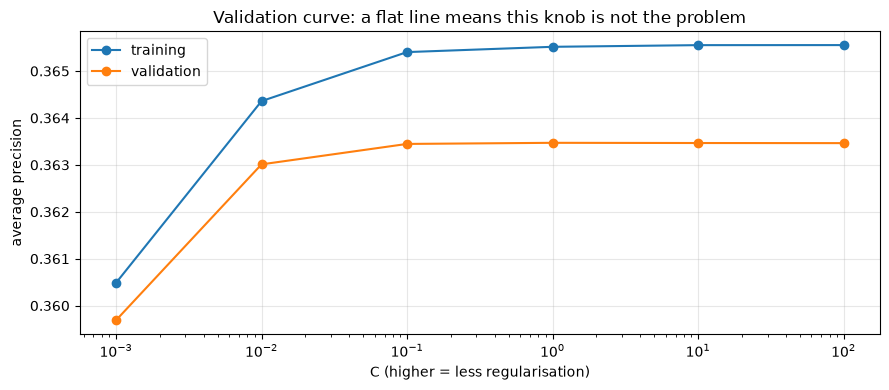

In [5]:
from sklearn.model_selection import validation_curve

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores, validation_scores = validation_curve(
    pipeline, X_train, y_train,
    param_name="logisticregression__C", param_range=C_values,
    cv=cv, scoring="average_precision", n_jobs=-1,
)

plt.semilogx(C_values, train_scores.mean(axis=1), marker="o", label="training")
plt.semilogx(C_values, validation_scores.mean(axis=1), marker="o", label="validation")
plt.xlabel("C (higher = less regularisation)")
plt.ylabel("average precision")
plt.title("Validation curve: a flat line means this knob is not the problem")
plt.legend()
plt.tight_layout()
plt.show()

Flat, and the two lines sit on top of each other. There is no regularisation
setting that helps, and there is no gap between training and validation — so the
model is **not overfitting**. If anything it is slightly underfitting: it is not
complex enough to squeeze more out of these features.

**A learning curve** varies the amount of training data instead. It answers the
single most expensive question in machine learning: *would more data help?*

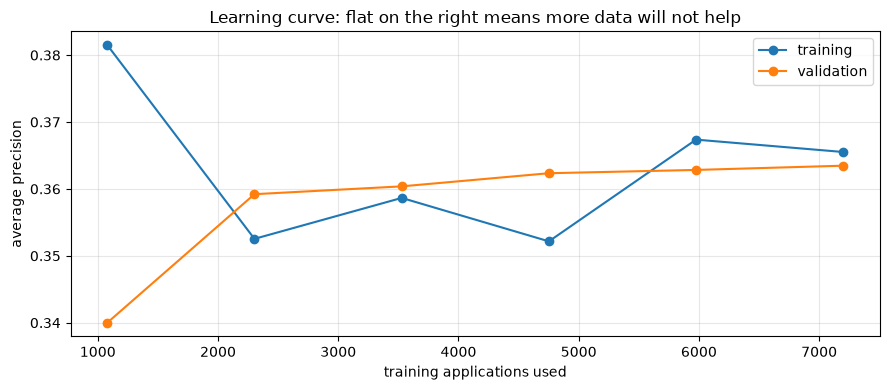

In [6]:
from sklearn.model_selection import learning_curve

sizes, train_scores, validation_scores = learning_curve(
    pipeline, X_train, y_train,
    train_sizes=np.linspace(0.15, 1.0, 6),
    cv=cv, scoring="average_precision", n_jobs=-1,
)

plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="training")
plt.plot(sizes, validation_scores.mean(axis=1), marker="o", label="validation")
plt.xlabel("training applications used")
plt.ylabel("average precision")
plt.title("Learning curve: flat on the right means more data will not help")
plt.legend()
plt.tight_layout()
plt.show()

The validation line climbs until about 3,500 applications and then flattens
completely. We have 9,000. **Doubling the dataset would buy us nothing.**

Put the two diagnoses together:

| Symptom | Diagnosis | What to do |
|---------|-----------|------------|
| Big gap between training and validation | Overfitting | More data, more regularisation, simpler model |
| Both curves low and converged | Underfitting (bias) | Better features, a more flexible model |
| Validation curve flat | The hyperparameter is irrelevant | Stop tuning it |
| Learning curve flat | More data will not help | Do not buy data |

Ours is the second and fourth rows: converged, flat, and not hyperparameter
limited. Tuning is exhausted, and buying data would be a waste of a budget.

That is not bad news. It is a **decision**, made with evidence, that the next
improvement has to come from somewhere else. So we go looking.

---

## 4. Error analysis: where is this model wrong?

An aggregate score is an average over very different situations. A model with 51%
recall might catch 80% of defaults in one part of the book and 20% in another —
and the second part is where your money is going.

Slice the test predictions by every grouping the business would recognise, and
look at recall, flag rate, and **missed money** in each.

In [7]:
model = pipeline.fit(X_train, y_train)
probabilities = model.predict_proba(X_test)[:, 1]

THRESHOLD = 0.20        # the capacity-feasible operating point from session 5

analysis = loans.loc[X_test.index, ["loan_amount", "sector", "employment_type"]].copy()
analysis["actual"] = y_test.to_numpy()
analysis["probability"] = probabilities
analysis["flagged"] = (probabilities >= THRESHOLD).astype(int)
analysis["missed_default"] = (analysis["actual"] == 1) & (analysis["flagged"] == 0)
analysis["size_band"] = pd.qcut(analysis["loan_amount"], 4,
                                labels=["smallest", "small", "large", "largest"])

def slice_report(column):
    grouped = analysis.groupby(column, observed=True)
    report = pd.DataFrame({
        "applications": grouped.size(),
        "defaults": grouped["actual"].sum(),
        "recall": grouped.apply(lambda g: g.loc[g["actual"] == 1, "flagged"].mean()),
        "flagged": grouped["flagged"].mean(),
        "missed_NPR_m": grouped.apply(
            lambda g: g.loc[g["missed_default"], "loan_amount"].sum() * 0.55 / 1e6),
    })
    return report.round(3)

print(slice_report("sector").to_string())

               applications  defaults  recall  flagged  missed_NPR_m
sector                                                              
Agriculture             418        42   0.452    0.191         5.722
Construction            319        58   0.621    0.279         3.804
Manufacturing           427        60   0.483    0.173         7.090
Service                 719        98   0.429    0.196        13.600
Tourism                 187        28   0.571    0.251         2.409
Trade                   930       119   0.546    0.205        13.249


In [8]:
print(slice_report("employment_type").to_string())
print()
print(slice_report("size_band").to_string())

                 applications  defaults  recall  flagged  missed_NPR_m
employment_type                                                       
Business Owner            682        79   0.443    0.179        10.179
Informal                  435        71   0.592    0.308         6.227
Salaried                 1036       147   0.483    0.192        17.373
Self-Employed             847       108   0.546    0.197        12.095

           applications  defaults  recall  flagged  missed_NPR_m
size_band                                                       
smallest            761        77   0.442    0.155         3.119
small               744        85   0.471    0.184         5.858
large               746       110   0.509    0.193        11.658
largest             749       133   0.579    0.298        25.240


Now read those three tables like an investigator.

**Sector.** Recall runs from 0.43 in Service to 0.62 in Construction. Service is
also the second-largest sector, so its weak recall leaks NPR 13.6m — the model is
worst where the volume is.

**Employment type.** Business Owners get recall 0.44 against Informal workers'
0.59. Salaried applicants leak the most money in absolute terms simply because
there are more of them.

**Loan size — and here is the finding.** Recall is 0.44 on the smallest loans and
0.58 on the largest, which sounds fine. But look at the money: the largest quarter
of loans accounts for **NPR 25.2m of missed defaults**, more than the other three
bands combined.

Of course it does. A missed default on a 2-million-rupee loan costs twenty times
a missed default on a 100,000-rupee loan — but our single threshold treats them
identically. We have been applying the same standard of proof to a decision worth
20 times as much.

---

## 5. Acting on the finding, without touching the model

The fix does not need a new model, new features, or new data. It needs the
threshold to know what is at stake.

Large loans get a **lower** threshold — flag them on weaker evidence, because
being wrong is expensive. Small loans get a **higher** one, freeing review
capacity to pay for it.

In [9]:
def total_cost(flagged):
    missed = analysis.loc[(analysis["actual"] == 1) & (flagged == 0), "loan_amount"].sum() * 0.55
    false_alarms = analysis.loc[(analysis["actual"] == 0) & (flagged == 1), "loan_amount"].sum() * 0.045
    return (missed + false_alarms) / 1e6


flat = (analysis["probability"] >= 0.20).astype(int)

size_aware_threshold = analysis["size_band"].map({
    "smallest": 0.25, "small": 0.25, "large": 0.15, "largest": 0.15,
}).astype(float)
size_aware = (analysis["probability"] >= size_aware_threshold).astype(int)

for label, flagged in [("one threshold (0.20)", flat), ("size-aware thresholds", size_aware)]:
    recall = flagged[analysis["actual"] == 1].mean()
    print(f"{label:<24} flagged {flagged.mean():.1%}   recall {recall:.3f}   "
          f"cost NPR {total_cost(flagged):.1f}m")

one threshold (0.20)     flagged 20.7%   recall 0.511   cost NPR 55.0m
size-aware thresholds    flagged 23.5%   recall 0.551   cost NPR 46.4m


**NPR 8.6 million saved, recall up from 0.511 to 0.551, and the flag rate stays
at 23.5% — inside the charter's 25% capacity.**

No retraining. No new features. The same probabilities, read with the knowledge
that not all mistakes cost the same.

This is why error analysis outranks tuning on most projects. The hyperparameter
search moved the score by 0.003 of measurement noise; twenty minutes of looking at
slices moved real money.

### What else to do with a bad slice

| Finding | Options |
|---------|---------|
| A slice is inherently harder | Accept it, document it, and monitor it separately |
| A slice has few training rows | Collect more of *that* slice — the learning curve was flat overall, not per slice |
| A slice behaves differently | Add a feature that captures the difference, or train a separate model |
| A slice carries more cost | Change its threshold — usually the cheapest fix, as above |
| A slice is a protected group | Stop. This is a fairness question, and it needs the business and compliance, not a quiet code change |

That last row is not optional. Our charter forbade protected attributes as
features, but a model can still perform unevenly across groups it was never given.
Slice analysis is how you find out — which is why it belongs in every review, not
just the ones where the aggregate score disappoints.

---

## 6. The tuning workflow, in order

1. **Fix the metric first** (session 5). Tuning against the wrong number
   optimises the wrong model very efficiently.
2. **Cross-validate the baseline** and record the fold spread. That spread is your
   noise floor for the rest of the project.
3. **Search hyperparameters** — grid if small, random if large, halving if
   expensive. Compare the winner to the baseline *in units of the fold spread*.
4. **Draw the two curves.** Validation curve: is this knob worth turning? Learning
   curve: would more data help?
5. **Slice the errors** by every grouping the business recognises, and look at
   money, not just rates.
6. **Act on the biggest slice finding** — often a threshold change, not a model change.
7. **Touch the test set once**, at the end, to report the number you will be held to.

Most teams do step 3 for two weeks and skip steps 4 to 6 entirely. That is the
habit this session exists to break.

---

## Your turn

**1. Honest folds.** Re-run the cross-validation with `TimeSeriesSplit(n_splits=5)`
on data sorted by `application_date`. How do the fold scores compare to the
shuffled version, and which number would you put in the charter?

**2. Random search.** Replace the boosting `GridSearchCV` with
`RandomizedSearchCV` over wider ranges (`learning_rate` between 0.01 and 0.3,
`max_iter` between 50 and 400, `max_depth` from 2 to 10), with `n_iter=20`. Does
it beat the grid, and how long does it take?

**3. Per-slice learning curves.** The overall learning curve was flat. Draw one
using only `sector == "Service"` rows. Is *that* slice data-limited even though
the whole book is not?

**4. Tune the size-aware thresholds.** Section 5 picked 0.15 and 0.25 by hand.
Search a small grid of (large-loan threshold, small-loan threshold) pairs and find
the cheapest combination that keeps the flag rate under 25%. How much more can you
save?

**5. Four bands, four thresholds.** Extend the idea: give each of the four size
bands its own threshold, chosen so that the *expected cost* of flagging equals the
expected cost of not flagging. Does this beat the two-level version?

**6. Slice by missingness.** Build a slice report on `income_missing`. Does the
model treat applicants with no documented income differently? Should it?

---

## If you remember nothing else

**One split is one sample.** Our folds ranged from 0.309 to 0.405 on the same
data. Always cross-validate, always report the spread.

**An improvement smaller than the fold spread is not an improvement.** Gradient
boosting "beat" logistic regression by 0.003 against noise of 0.032.

**Read the two curves before spending money.** A flat validation curve means stop
tuning; a flat learning curve means do not buy data. Both were flat here.

**Aggregate scores hide everything that matters.** The largest quarter of loans
carried NPR 25.2m of missed defaults — more than the other three quarters
combined.

**Not all mistakes cost the same, so not all thresholds should be the same.**
Size-aware thresholds saved NPR 8.6m with no retraining at all.

**Touch the test set once.** Everything in this session happened on training data
and cross-validation folds. The test set is the final exam, not a practice paper.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Validation set** | Data used to choose between models; distinct from the test set |
| **k-fold cross-validation** | Rotating validation across k folds and averaging |
| **Stratified k-fold** | Folds that preserve the class balance |
| **`TimeSeriesSplit`** | Folds that always train on earlier data and validate on later |
| **Fold spread** | Variation between folds; your noise floor for comparing models |
| **Grid search** | Exhaustive search over a parameter grid |
| **Random search** | Sampling parameter combinations from ranges |
| **Halving search** | Eliminating weak candidates on small subsets before spending full data |
| **Validation curve** | Score against one hyperparameter |
| **Learning curve** | Score against training set size |
| **Bias / underfitting** | Both curves low and converged — the model is too simple |
| **Variance / overfitting** | Training far above validation |
| **Slice analysis** | Measuring performance within business-meaningful subgroups |

## Further reading

- scikit-learn User Guide, *Cross-validation*, *Tuning the hyper-parameters*, and
  *Validation curves* — the three pages behind this session.
- Andrew Ng, *Machine Learning Yearning* — chapters on error analysis and on
  reading learning curves; short, practical, free.
- Google's *Rules of Machine Learning*, rules 22–30 — when to stop tuning and
  start looking at your errors.
- Barocas, Hardt and Narayanan, *Fairness and Machine Learning* — for the last
  row of the slice-action table.

---

**Next session:** *ML Pipelines and Experiment Tracking* — making all of this
reproducible, so that "the model from last Tuesday" is a thing you can actually
retrieve.